Importacion De Libreria Pandas Para Visualizar Nuestros Datos

In [2]:
import pandas as pd
datos=pd.read_csv("titanic_data.csv")

In [3]:
datos.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Usamos Seaborn Para Graficar Datos

<Axes: xlabel='Survived', ylabel='count'>

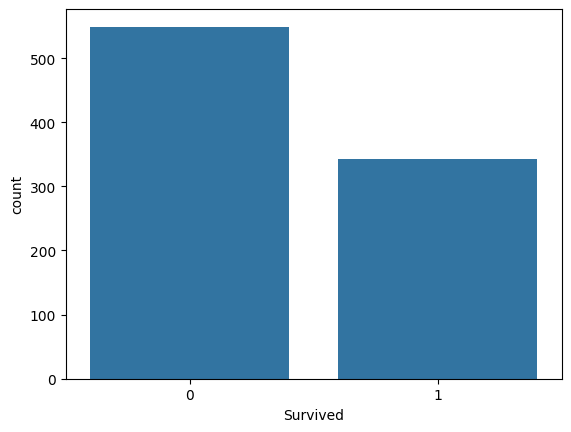

In [4]:
import seaborn as sb
sb.countplot(x="Survived", data=datos)

<Axes: xlabel='Survived', ylabel='count'>

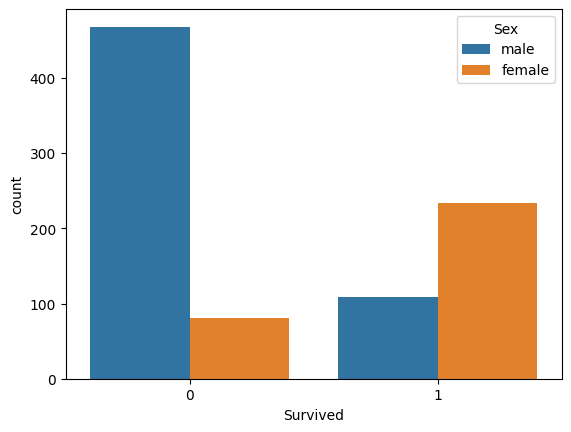

In [5]:
sb.countplot(x="Survived", data=datos, hue="Sex")

Sumamos los Datos

In [6]:
datos.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Graficamos Los Datos de la edad para poder vizualizar cual era la media de la edad de los pasajeros

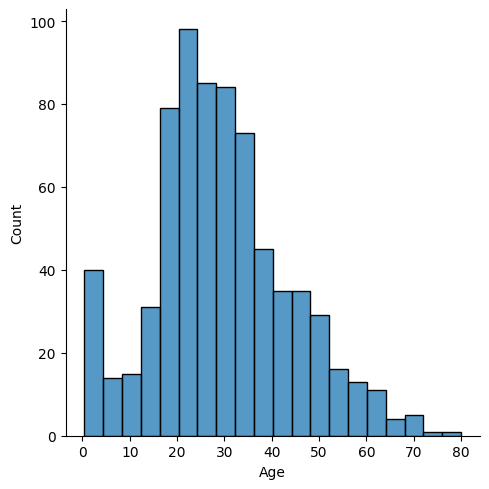

In [7]:
sb.displot(x="Age", data=datos)

Vizualizamos las edades de los pasajeros

In [8]:
datos['Age']

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


La Media de la edad

In [9]:
datos['Age'].mean()

np.float64(29.69911764705882)

Rellena Los Espacios Vacios

In [10]:
datos['Age'].fillna(datos['Age'].mean())

,Age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
886,27.000000
887,19.000000
888,29.699118
889,26.000000


In [11]:
datos["Age"] = datos['Age'].fillna(datos['Age'].mean())

Vemos Los Datos Actualizados

In [12]:
datos["Age"]

,Age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
886,27.000000
887,19.000000
888,29.699118
889,26.000000


Vemos que la Edad Ya no tiene Espacios Vacios

In [13]:
datos.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Borramos Cabin

In [14]:
datos= datos.drop(["Cabin"],axis=1)

Vemos EL Contenido de Embarked

In [15]:
datos["Embarked"].value_counts()

,count
Embarked,
S,644
C,168
Q,77


Hace Que nos Quedemos solo con las filas completas y que no tengan datos faltantes

In [16]:
datos = datos.dropna()

Vizualizamos Los Datos Actualizados

In [17]:
datos.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


Borramos Las filas "Name,PassengerId y Ticket"

In [18]:
datos = datos.drop(["Name","PassengerId","Ticket"],axis=1)

Convierte Los sexos en 0 y 1 para hacerlos datos numericos

In [19]:
dummies_sex = pd.get_dummies(datos["Sex"],drop_first= True)

Actualizamos Los datos y eliminamos los anteriores

In [20]:
datos = datos.join(dummies_sex)
datos = datos.drop(["Sex"],axis=1)

Vizualizamos con seaborn que tipo de embarcacion tenia mas oportunidad de sobrevivir con tu genero

<Axes: xlabel='Survived', ylabel='count'>

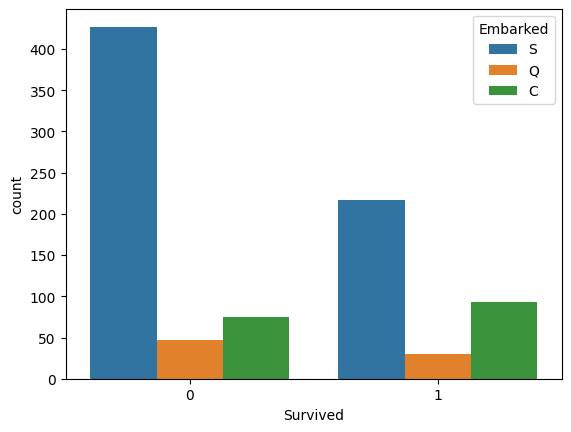

In [21]:
sb.countplot(x="Survived", data=datos, hue="Embarked")

Creamos una nueva variable para hacer numerico la fila embarked

In [22]:
dummies_embarked = pd.get_dummies(datos["Embarked"],drop_first= True)

Actualizamos y borramos los datos

In [23]:
datos = datos.join(dummies_embarked)
datos = datos.drop(["Embarked"],axis=1)

Hacemos una matriz de confusion para vizualizar datos comunes

<Axes: >

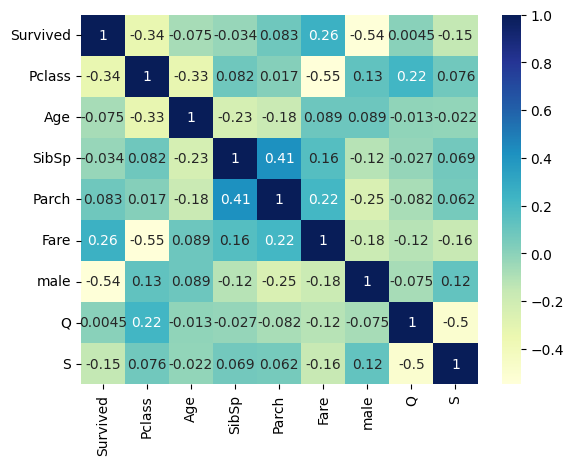

In [24]:
sb.heatmap(datos.corr(), annot=True,cmap="YlGnBu")

Usamos seaborn para vizualizar que clase sobrevivio mas

<Axes: xlabel='Survived', ylabel='count'>

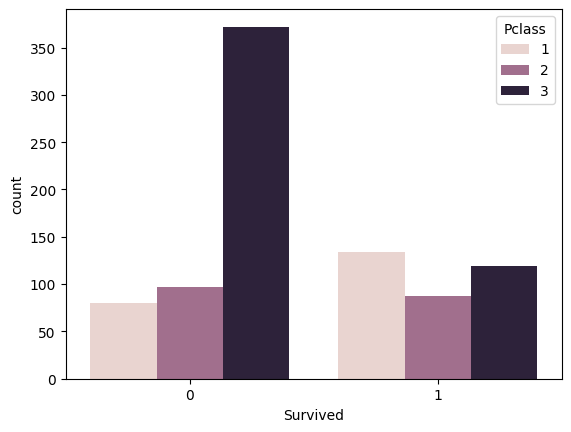

In [25]:
sb.countplot(x="Survived", data=datos, hue="Pclass")

Eliminamos y actualizamos  los datos de los sobrevivientes

In [26]:
x = datos.drop(["Survived"],axis=1)
y = datos["Survived"]

Usamos Sklearn para crear un modelo de de machine learning

In [27]:
from sklearn.model_selection import train_test_split
x_ent,x_pru,y_ent,y_pru = train_test_split(x,y,test_size=0.2)

Usamos Clasificador De Arbol de Decision y creamos un modelo

In [29]:
from sklearn.tree import DecisionTreeClassifier

modelo = DecisionTreeClassifier(max_depth=50)
modelo.fit(x_ent,y_ent)
predicciones = modelo.predict(x_pru)

Vemos el Porcentaje de exactitud

In [30]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pru,predicciones)

0.8146067415730337

entrenamos el modelo y usamos "For" para poder vizualizar del 1 al 15 que nivel de profundidad es mas exacto para usar tambien creamos la variable "Resultados" para guardar los datos

In [33]:
from sklearn.tree import DecisionTreeClassifier
resultados=[]
for i in range(1,15):
  modelo = DecisionTreeClassifier(max_depth=i)
  modelo.fit(x_ent,y_ent)
  predicciones = modelo.predict(x_pru)
  exactitud = accuracy_score(y_pru,predicciones)
  print(f"Resultado para ={i}: {exactitud}")
  resultados.append(exactitud)

Resultado para =1: 0.8202247191011236
Resultado para =2: 0.797752808988764
Resultado para =3: 0.8426966292134831
Resultado para =4: 0.8370786516853933
Resultado para =5: 0.8370786516853933
Resultado para =6: 0.8146067415730337
Resultado para =7: 0.8370786516853933
Resultado para =8: 0.848314606741573
Resultado para =9: 0.848314606741573
Resultado para =10: 0.8426966292134831
Resultado para =11: 0.8539325842696629
Resultado para =12: 0.8258426966292135
Resultado para =13: 0.8258426966292135
Resultado para =14: 0.8370786516853933


Usamos Seaborn para graficar la variable "Resultado" y saber cual modelo es mejor

<Axes: >

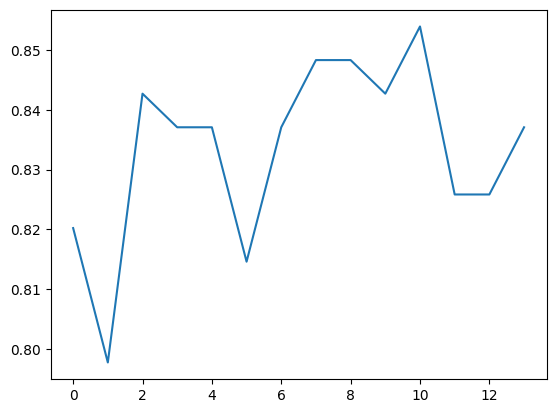

In [34]:
sb.lineplot(data=resultados)

Usamos el modelo con el mejor porcentaje en mi caso el 11

In [35]:
modelo = DecisionTreeClassifier(max_depth=11)
modelo.fit(x_ent,y_ent)
predicciones = modelo.predict(x_pru)
exactitud = accuracy_score(y_pru,predicciones)

Hace un reporte del modelo predictivo

In [37]:
from sklearn.metrics import classification_report
print(classification_report(y_pru,predicciones))

              precision    recall  f1-score   support

           0       0.85      0.94      0.89       113
           1       0.87      0.72      0.79        65

    accuracy                           0.86       178
   macro avg       0.86      0.83      0.84       178
weighted avg       0.86      0.86      0.86       178



Hacemos una matriz de confusion para hacer una mejor vizualizacion

In [38]:
from sklearn.metrics import confusion_matrix
pd.DataFrame(confusion_matrix(y_pru,predicciones),columns=["Pred: No","Pred: Si"],index=["Real: No","Real: Si"])

,Pred: No,Pred: Si
Real: No,106,7
Real: Si,18,47


Vizualizamos las columnas de entrenamiento

In [41]:
x_ent.columns

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'male', 'Q', 'S'], dtype='object')

Graficamos el arbol de decisiones usamos sklearn tree como modelo
usamos matplot para graficar


[Text(0.44482421875, 0.9583333333333334, 'male <= 0.5\n0.474\n711\n[436, 275]\nMurio'),
 Text(0.266015625, 0.875, 'Pclass <= 2.5\n0.395\n255\n[69, 186]\nVivio'),
 Text(0.355419921875, 0.9166666666666667, 'True  '),
 Text(0.11875, 0.7916666666666666, 'Age <= 2.5\n0.112\n134\n[8, 126]\nVivio'),
 Text(0.0875, 0.7083333333333334, 'Pclass <= 1.5\n0.5\n2\n[1, 1]\nMurio'),
 Text(0.075, 0.625, '0.0\n1\n[1, 0]\nMurio'),
 Text(0.1, 0.625, '0.0\n1\n[0, 1]\nVivio'),
 Text(0.15, 0.7083333333333334, 'Fare <= 28.856\n0.1\n132\n[7, 125]\nVivio'),
 Text(0.125, 0.625, 'Fare <= 28.231\n0.194\n55\n[6, 49]\nVivio'),
 Text(0.1125, 0.5416666666666666, 'Age <= 56.0\n0.168\n54\n[5, 49]\nVivio'),
 Text(0.0875, 0.4583333333333333, 'Parch <= 0.5\n0.142\n52\n[4, 48]\nVivio'),
 Text(0.075, 0.375, 'Age <= 27.5\n0.193\n37\n[4, 33]\nVivio'),
 Text(0.05, 0.2916666666666667, 'Fare <= 23.5\n0.346\n9\n[2, 7]\nVivio'),
 Text(0.0375, 0.20833333333333334, 'Fare <= 17.429\n0.444\n6\n[2, 4]\nVivio'),
 Text(0.025, 0.125, 'Age <

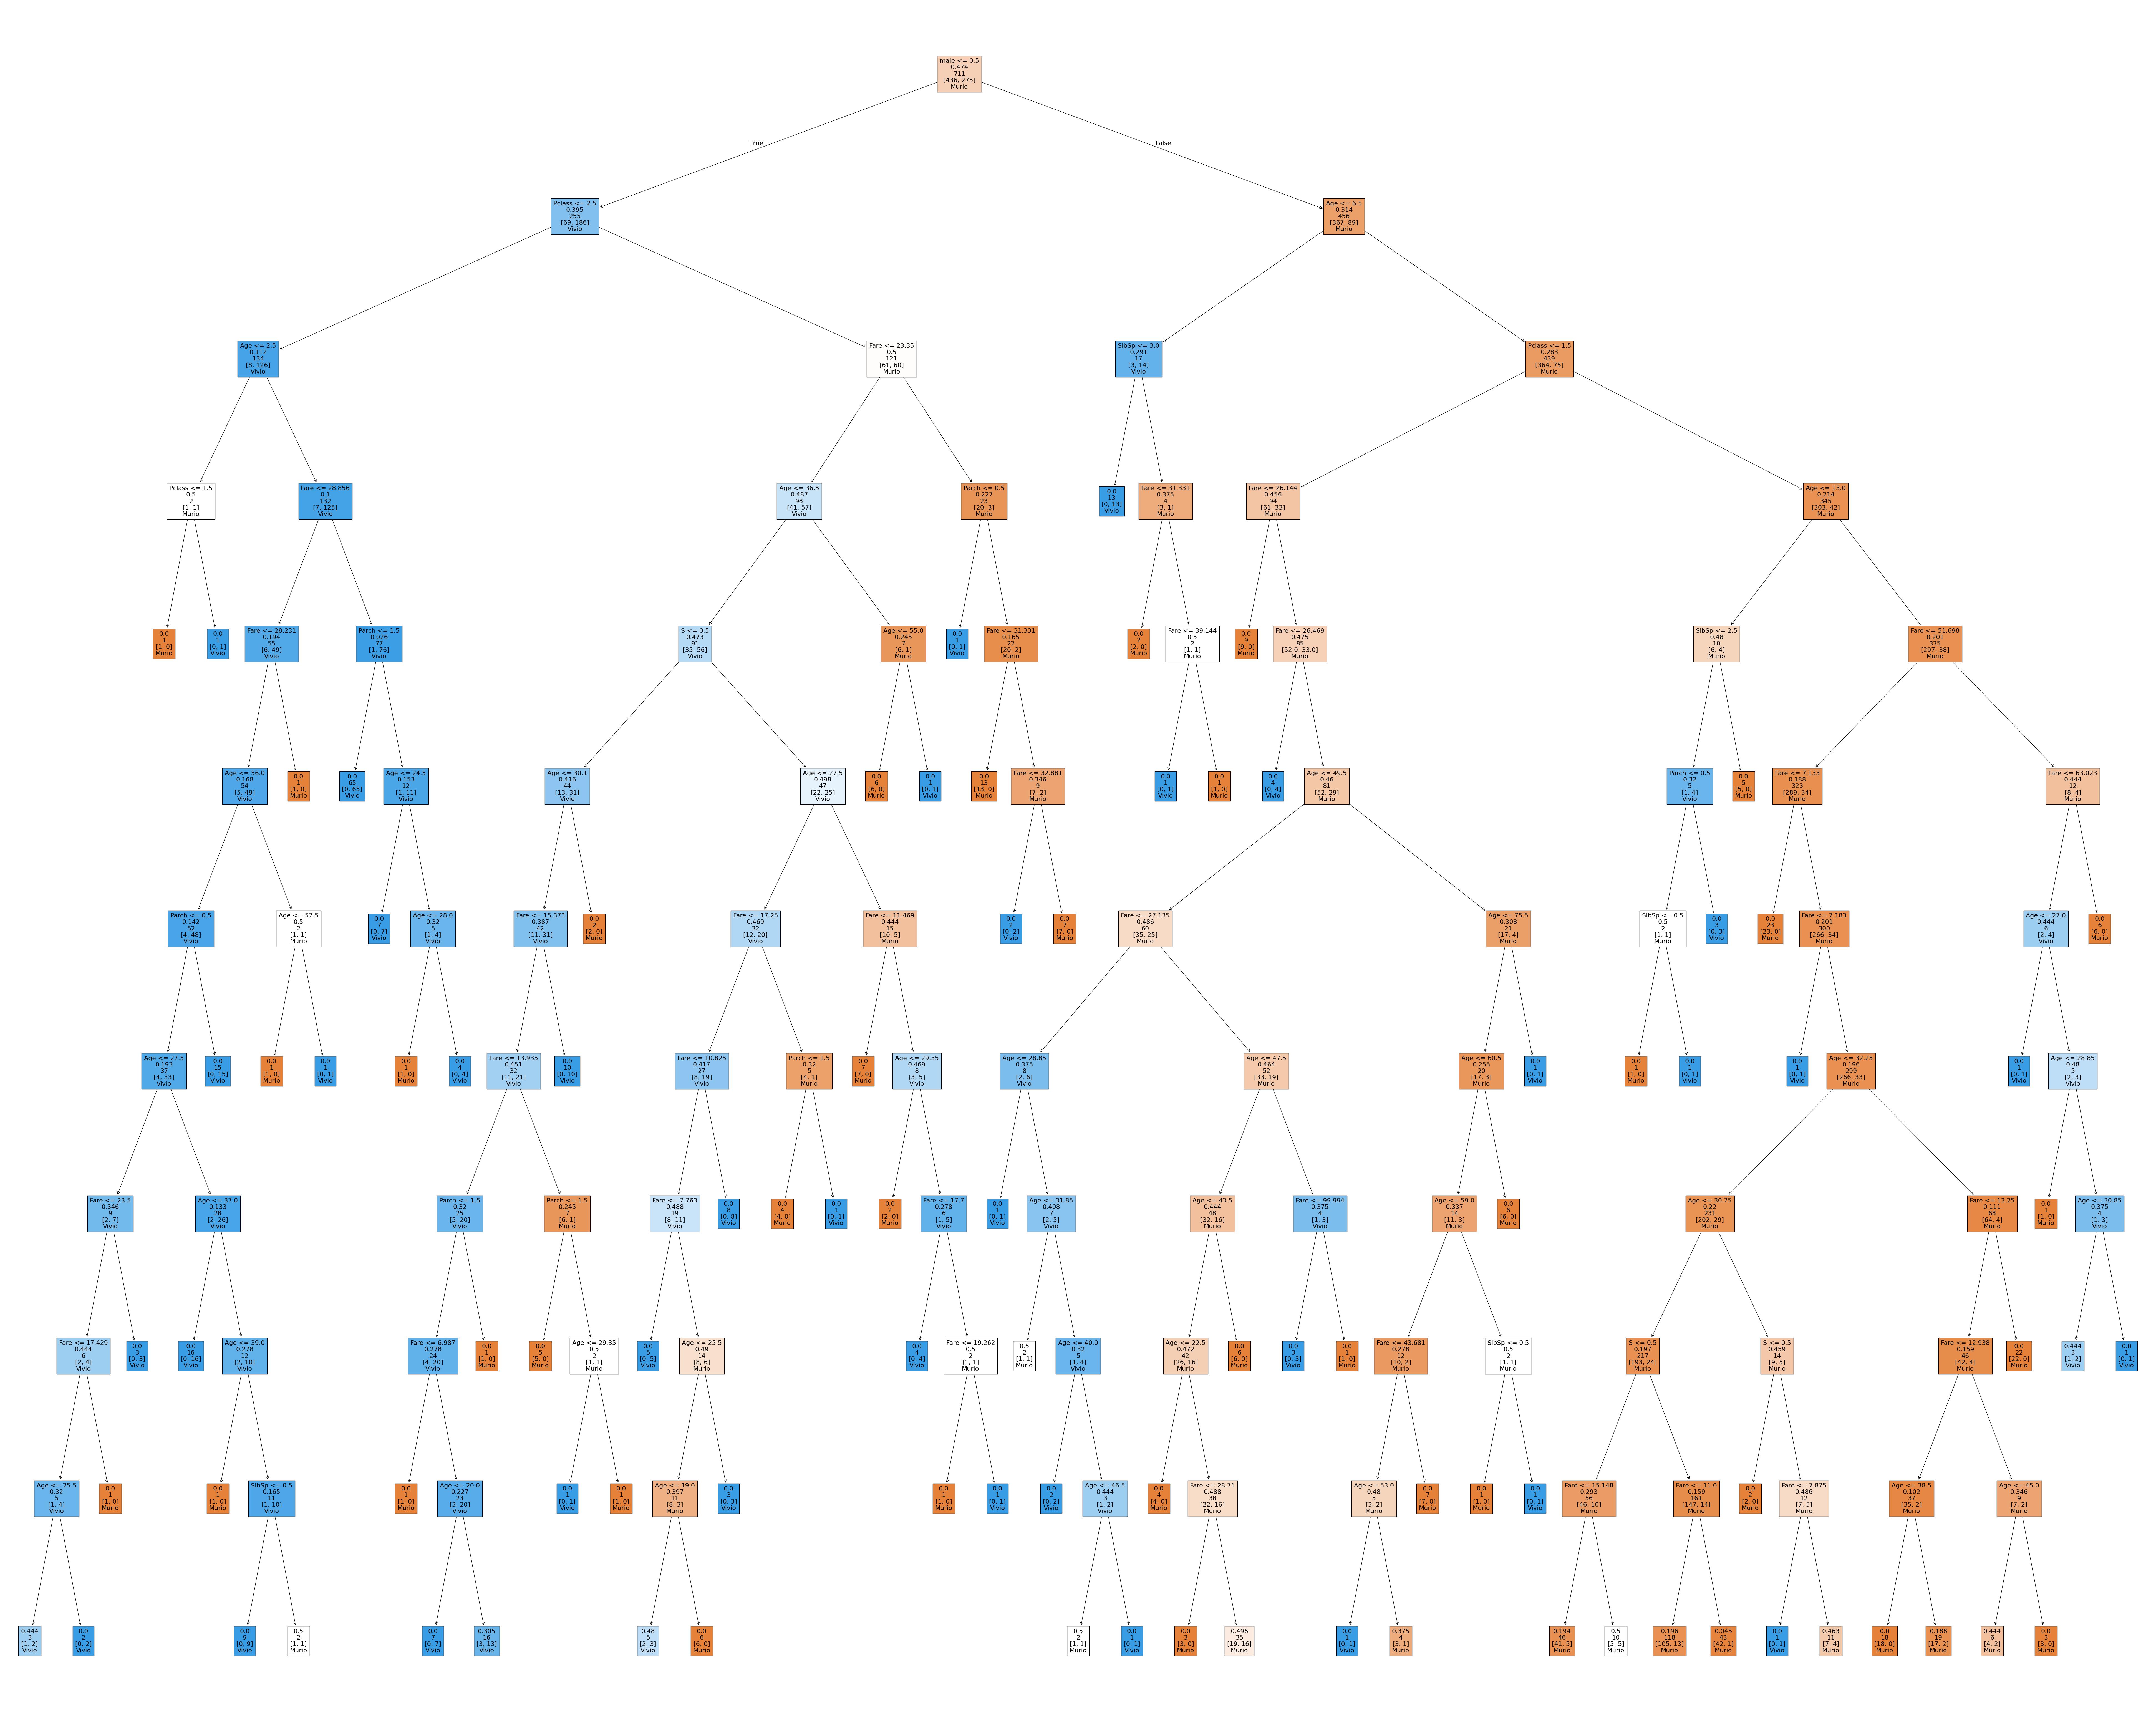

In [44]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(100,80))
plot_tree(
    modelo,
    feature_names= x_ent.columns,
    class_names=["Murio","Vivio"],
    filled=True,
    label="none"
          )